# 6주차: 실전 딥러닝 — Overfitting, 정규화(regularization, 규제), 가중치 초기화, Vanishing Gradient

> **수업 구성**
> - Part 1 (강의 영상 ~40분): 이론 설명 — 미리 보고 오세요
> - Part 2 (교실 실습 100분): 빈칸 채우기 실습

---

## 0. 지난 주 복습 & 이번 주 연결

5주차에서 DNN을 자유롭게 쌓을 수 있게 됐습니다.
실습 B-2에서 Train Loss는 계속 감소하는데 Test Loss는 올라가는 현상을 관찰했습니다.

이번 주는 그 현상의 원인과 해결책을 다룹니다.

| 현상 | 원인 | 이번 주 해결책 |
|------|------|--------------|
| Train↓ Test↑ (갈라짐) | Overfitting | L2 정규화, Dropout |
| Train↑ Test↑ (둘 다 나쁨) | Underfitting | 더 큰 모델, 더 긴 학습 |
| 깊은 층 학습 안 됨 | Vanishing Gradient | He/Xavier 초기화, ReLU |


## 1. Bias / Variance 진단

모델이 잘 안 될 때 **어떤 문제인지 먼저 진단**해야 합니다.

### 진단 기준

| 상황 | Train Loss | Test Loss | 진단 |
|------|-----------|----------|------|
| A | 높음 | 높음 | **High Bias** (Underfitting) |
| B | 낮음 | 낮음 | 이상적 |
| C | 낮음 | 높음 | **High Variance** (Overfitting) |
| D | 높음 | 매우 높음 | High Bias + High Variance |

### 처방

$$\text{High Bias} \Rightarrow \text{더 큰 모델, 더 긴 학습, 다른 아키텍처}$$

$$\text{High Variance} \Rightarrow \text{더 많은 데이터, 정규화(L2, Dropout), Early Stopping}$$


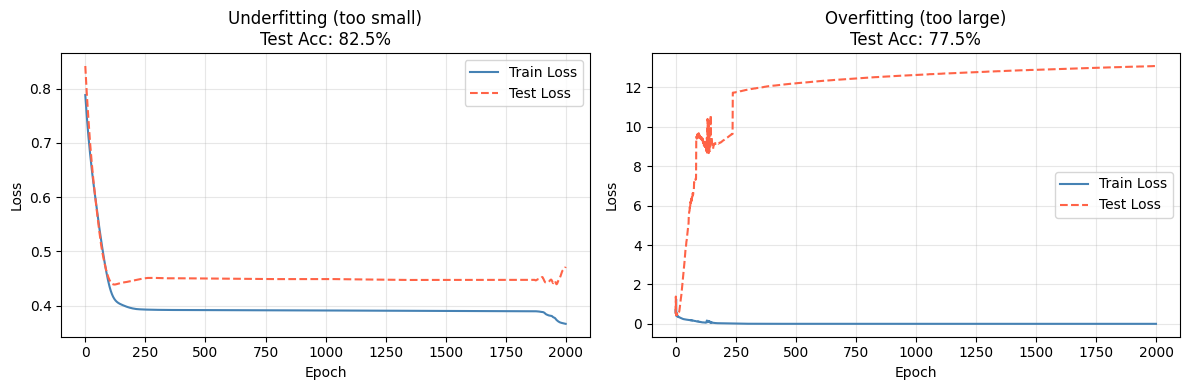

Underfitting — Train: 0.366, Test: 0.472
Overfitting  — Train: 0.000, Test: 13.089


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

# Dataset
X_np, y_np = make_moons(n_samples=200, noise=0.4, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_np, y_np, test_size=0.2, random_state=42)
X_train = torch.tensor(X_tr, dtype=torch.float32)
y_train = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(X_te, dtype=torch.float32)
y_test  = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)

def make_dnn(dims):
    layers = []
    for i in range(len(dims)-1):
        layers.append(nn.Linear(dims[i], dims[i+1]))
        if i < len(dims)-2:
            layers.append(nn.ReLU())
    layers.append(nn.Sigmoid())
    return nn.Sequential(*layers)

def train_eval(model, epochs=2000, lr=0.01):
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.BCELoss()
    tr_hist, te_hist = [], []
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        l = crit(model(X_train), y_train); l.backward(); opt.step()
        tr_hist.append(l.item())
        model.eval()
        with torch.no_grad():
            te_hist.append(crit(model(X_test), y_test).item())
    with torch.no_grad():
        acc = ((model(X_test)>0.5).float()==y_test).float().mean().item()
    return tr_hist, te_hist, acc

torch.manual_seed(42)
m_under = make_dnn([2, 2, 1])        # underfitting: too small
torch.manual_seed(42)
m_over  = make_dnn([2,256,256,256,1]) # overfitting: too large

tr_u, te_u, acc_u = train_eval(m_under)
tr_o, te_o, acc_o = train_eval(m_over)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tr, te, acc, title in zip(axes,
        [tr_u, tr_o], [te_u, te_o], [acc_u, acc_o],
        ["Underfitting (too small)", "Overfitting (too large)"]):
    ax.plot(tr, label='Train Loss', color='steelblue')
    ax.plot(te, label='Test Loss',  color='tomato', linestyle='--')
    ax.set_title(f"{title}\nTest Acc: {acc*100:.1f}%")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Underfitting — Train: {tr_u[-1]:.3f}, Test: {te_u[-1]:.3f}")
print(f"Overfitting  — Train: {tr_o[-1]:.3f}, Test: {te_o[-1]:.3f}")


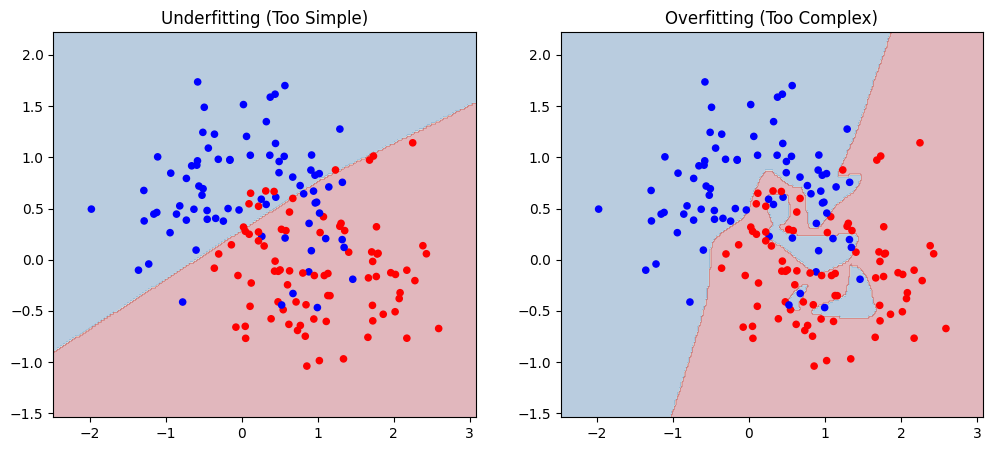

In [2]:
def plot_decision_boundary(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    model.eval()
    with torch.no_grad():
        Z = model(torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float())
        Z = (Z > 0.5).float().reshape(xx.shape).numpy()

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu_r')
    #ax.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='RdBu_r', s=20)
    ax.scatter(X[:,0], X[:,1], c=['blue' if l==0 else 'red' for l in y], s=20)
    ax.set_title(title)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(m_under, X_train.numpy(), y_train.numpy(), "Underfitting (Too Simple)", axes[0])
plot_decision_boundary(m_over, X_train.numpy(), y_train.numpy(), "Overfitting (Too Complex)", axes[1])
plt.show()

## 2. L2 정규화 (Weight Decay)

### 아이디어

가중치가 커지면 (1) 입력이 큰 출력으로 나타나므로 노이즈에 민감해지고 (2) linear 값이 커져서 활성화 함수의 포화 영역에 맵핑되므로, 기울기 소실 (Vanishing Gradient) 문제도 발생할 수 있음. 따라서 가중치가 너무 커지지 않도록 Loss에 페널티 항을 추가합니다.

$$\mathcal{L}_{\text{reg}} = \mathcal{L}_{\text{BCE}} + \frac{\lambda}{2m} \sum_{l} \|W^{[l]}\|_F^2$$

- $\lambda$: 정규화 강도 (하이퍼파라미터)
- $\|W\|_F^2$: Frobenius norm — 가중치 원소의 제곱합
- 효과: 가중치를 0에 가깝게 유지 → 모델이 덜 복잡해짐

### PyTorch에서 사용법

`optimizer`의 `weight_decay` 파라미터 하나로 간단하게 적용됩니다. `weight_decay`는 weight를 일정 비율로 줄이는 옵션이지만 L2 정규화와 같이 가중치를 0에 가깝게 유지시키는 효과 나타냄

```python
# ❌ 수동 구현 (불필요)
loss = bce_loss + lambda_ * sum(p.pow(2).sum() for p in model.parameters())

# ✅ PyTorch 방식 (권장)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-3)
```

내부적으로 매 스텝마다 gradient에 $\lambda W$ 를 더하는 효과가 납니다.


## 2.1 가중치 감쇠(Weight Decay)의 구현 원리

### 1) 수학적 배경: L2 정규화와 손실 함수
L2 정규화를 적용하면 모델의 원래 손실 함수($\mathcal{L}_{BCE}$)에 가중치의 제곱합 항이 추가됩니다.
$$\text{Total Loss} = \mathcal{L}_{BCE} + \frac{\lambda}{2} \sum \|W\|^2$$
이때 $\lambda$는 정규화 강도를 조절하는 하이퍼파라미터입니다.

### 2) 미분(Gradient)의 변화
학습은 이 'Total Loss'를 최소화하기 위해 가중치($W$)에 대한 미분값(Gradient)을 구해 가중치를 업데이트하는 과정입니다. 위 식을 미분하면 다음과 같은 결과가 나옵니다.
* **원래 손실의 미분값:** $\frac{\partial \mathcal{L}_{BCE}}{\partial W}$
* **정규화 항의 미분값:** $\frac{\partial}{\partial W} (\frac{\lambda}{2} W^2) = \lambda W$

따라서 **최종적인 미분값(Gradient)** 은 **(원래 미분값 + $\lambda W$)** 가 됩니다.

### 3) "Gradient에 $\lambda W$를 더해준다"의 의미
PyTorch의 옵티마이저에서 `weight_decay` 파라미터를 설정하면, 가중치를 업데이트하기 직전에 계산된 기울기(Gradient)에 **현재 가중치 값의 일정 비율($\lambda W$)을 강제로 더해줍니다.**

이렇게 수정된 기울기를 사용하여 가중치를 업데이트하면 결과적으로 다음과 같은 식이 유도됩니다.
$$W_{new} = W_{old} - \eta \times (\text{Gradient} + \lambda W_{old})$$
$$W_{new} = (1 - \eta \lambda) W_{old} - \eta \times \text{Gradient}$$
*(단, $\eta$는 학습률)*

### 4) 결론
위 식에서 보듯, 매 스텝마다 가중치($W_{old}$)에 $(1 - \eta \lambda)$라는 1보다 작은 값이 곱해지게 됩니다.
결과적으로 가중치가 크면 클수록 더 큰 값($\lambda W$)이 기울기에 더해져 다음 단계에서 더 많이 감소하게 되며, 이를 통해 **가중치가 0에 가깝게 유지되도록 '감쇠(Decay)'시켜 모델의 복잡도를 제어**하게 됩니다.

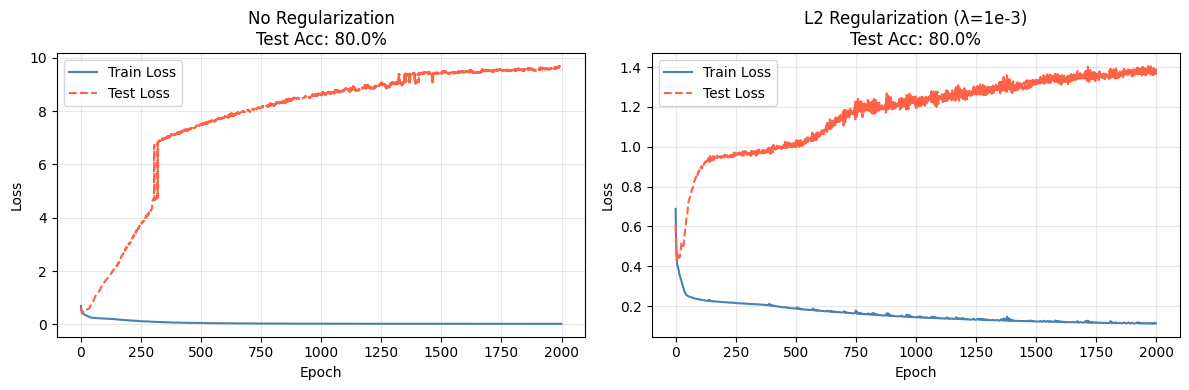

In [3]:
torch.manual_seed(42)
m_no_reg  = make_dnn([2,64,64,1])
torch.manual_seed(42)
m_with_reg = make_dnn([2,64,64,1])

def train_eval_wd(model, weight_decay=0.0, epochs=2000):
    opt  = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=weight_decay)
    crit = nn.BCELoss()
    tr_hist, te_hist = [], []
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        l = crit(model(X_train), y_train); l.backward(); opt.step()
        tr_hist.append(l.item())
        model.eval()
        with torch.no_grad():
            te_hist.append(crit(model(X_test), y_test).item())
    with torch.no_grad():
        acc = ((model(X_test)>0.5).float()==y_test).float().mean().item()
    return tr_hist, te_hist, acc

tr_n, te_n, acc_n = train_eval_wd(m_no_reg,   weight_decay=0.0)
tr_r, te_r, acc_r = train_eval_wd(m_with_reg, weight_decay=1e-3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tr, te, acc, title in zip(axes,
        [tr_n, tr_r], [te_n, te_r], [acc_n, acc_r],
        ["No Regularization", "L2 Regularization (λ=1e-3)"]):
    ax.plot(tr, label='Train Loss', color='steelblue')
    ax.plot(te, label='Test Loss',  color='tomato', linestyle='--')
    ax.set_title(f"{title}\nTest Acc: {acc*100:.1f}%")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


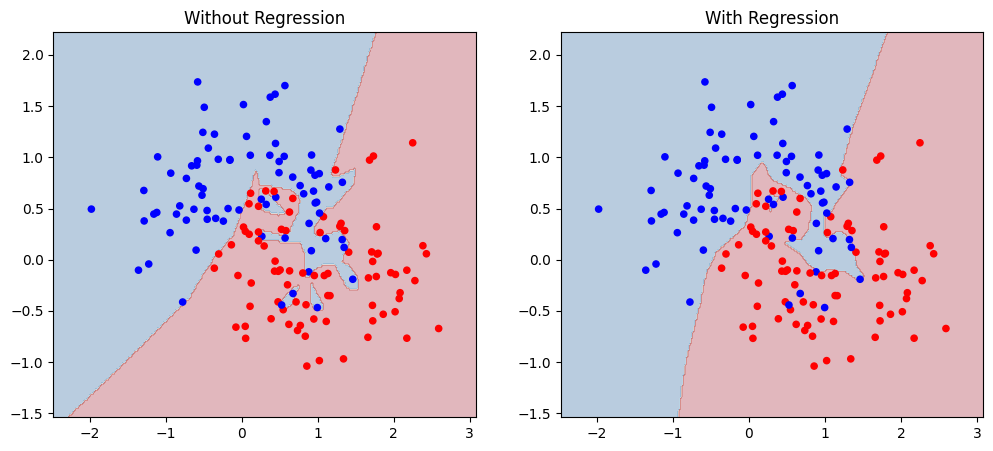

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(m_no_reg, X_train.numpy(), y_train.numpy(), "Without Regression", axes[0])
plot_decision_boundary(m_with_reg, X_train.numpy(), y_train.numpy(), "With Regression", axes[1])
plt.show()

## 3. Dropout

### 아이디어

학습 중 매 forward pass마다 각 뉴런을 확률 $p$로 **무작위로 비활성화**합니다.

- 훈련 시: 뉴런을 랜덤하게 끄고, 남은 뉴런의 출력을 $\frac{1}{1-p}$ 배 스케일링
- 평가 시: 모든 뉴런 사용 (비활성화 없음)

효과: 특정 뉴런에 의존하지 못하게 해서 더 **강건한(robust)** 표현을 학습

> ⚠️ 이래서 `model.train()` / `model.eval()` 구분이 중요합니다!
> Dropout은 두 모드에서 **다르게 동작**합니다.

### PyTorch 사용법

```python
model = nn.Sequential(
    nn.Linear(2, 64), nn.ReLU(),
    nn.Dropout(p=0.5),           # 50% 확률로 뉴런 비활성화
    nn.Linear(64, 64), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(64, 1), nn.Sigmoid()
)
```


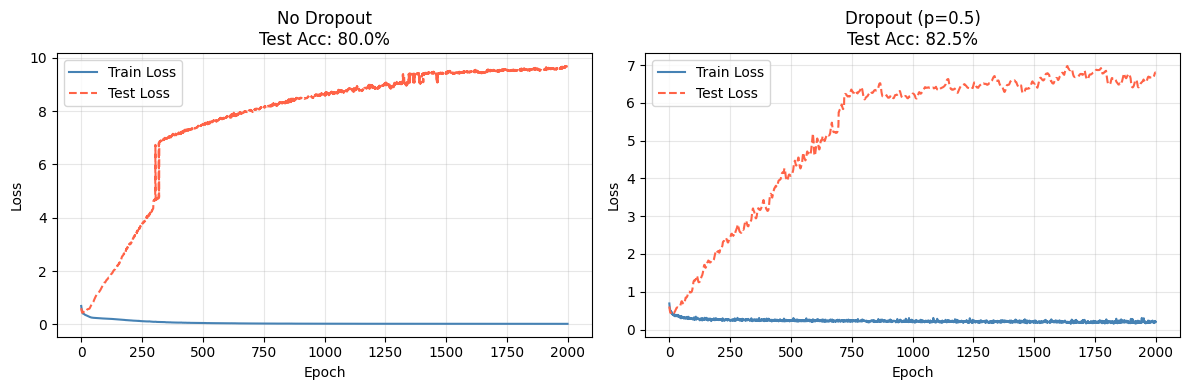

In [5]:
torch.manual_seed(42)
m_dropout = nn.Sequential(
    nn.Linear(2, 64),  nn.ReLU(), nn.Dropout(p=0.5),
    nn.Linear(64, 64), nn.ReLU(), nn.Dropout(p=0.5),
    nn.Linear(64, 1),  nn.Sigmoid()
)

def train_eval_dropout(model, epochs=2000, lr=0.01):
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.BCELoss()
    tr_hist, te_hist = [], []
    for _ in range(epochs):
        model.train()   # Dropout ON
        opt.zero_grad()
        l = crit(model(X_train), y_train); l.backward(); opt.step()
        tr_hist.append(l.item())
        model.eval()    # Dropout OFF
        with torch.no_grad():
            te_hist.append(crit(model(X_test), y_test).item())
    with torch.no_grad():
        acc = ((model(X_test)>0.5).float()==y_test).float().mean().item()
    return tr_hist, te_hist, acc

torch.manual_seed(42)
m_no_drop = make_dnn([2,64,64,1])
tr_nd, te_nd, acc_nd = train_eval_wd(m_no_drop, epochs=2000)
tr_d,  te_d,  acc_d  = train_eval_dropout(m_dropout)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tr, te, acc, title in zip(axes,
        [tr_nd, tr_d], [te_nd, te_d], [acc_nd, acc_d],
        ["No Dropout", "Dropout (p=0.5)"]):
    ax.plot(tr, label='Train Loss', color='steelblue')
    ax.plot(te, label='Test Loss',  color='tomato', linestyle='--')
    ax.set_title(f"{title}\nTest Acc: {acc*100:.1f}%")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


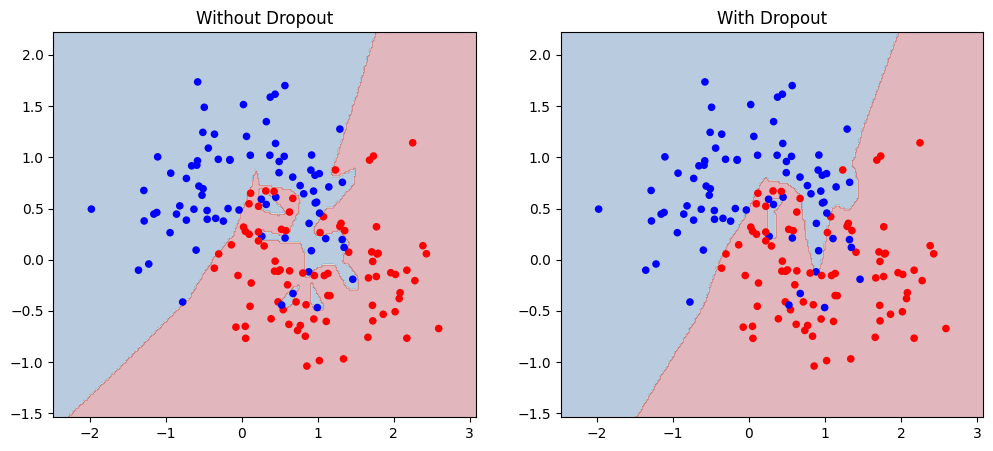

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(m_no_drop, X_train.numpy(), y_train.numpy(), "Without Dropout", axes[0])
plot_decision_boundary(m_dropout, X_train.numpy(), y_train.numpy(), "With Dropout", axes[1])
plt.show()

## 4. 가중치 초기화 — Xavier / He

4주차에서 Zero init의 문제(symmetry)를 확인했습니다.
그럼 랜덤 초기화는 어떻게 해야 할까요?

### 문제: 분산이 너무 크거나 작으면?

- 너무 크게 초기화 → 활성화 값이 포화(saturation) → gradient ≈ 0
- 너무 작게 초기화 → 신호가 레이어를 거치며 소실

### 해결: 레이어 크기에 맞게 분산을 조정

| 이름 | 권장 활성화 | &nbsp;&nbsp;&nbsp;&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 초기화 방식 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;  | 비고 |
|------|------------|-----------|-----------|
| Xavier (Glorot) | Sigmoid, Tanh | $W \sim \mathcal{U}\!\left(-\frac{\sqrt{6}}{\sqrt{n_{in}+n_{out}}},\ \frac{\sqrt{6}}{\sqrt{n_{in}+n_{out}}}\right)$ | 0 근처 선형/대칭 함수
| He (Kaiming) | ReLU | $W \sim \mathcal{N}\!\left(0,\ \frac{2}{n_{in}}\right)$ | ReLU는 비선형 함수

PyTorch `nn.Linear`의 기본값은 **Kaiming Uniform** (He와 유사)입니다.


/tmp/ipykernel_15073/1809591803.py:52: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(h_pad=4.0)


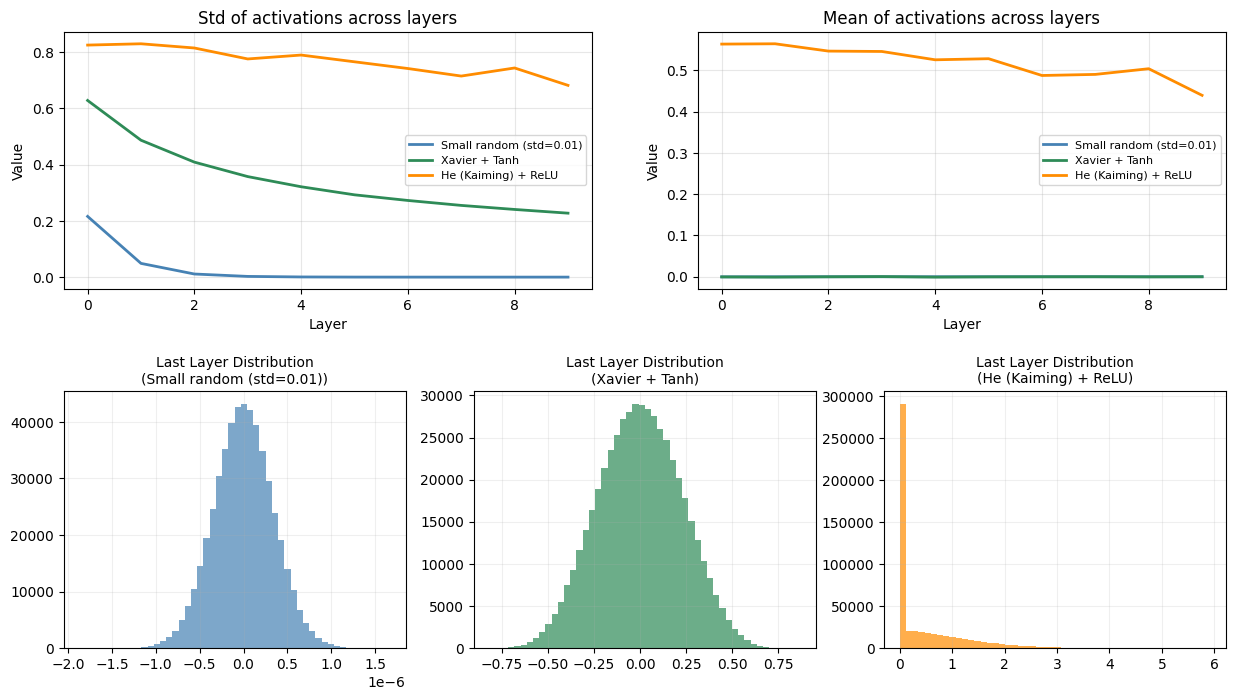

체크포인트:
1. Small random: 층이 깊어질수록 분포가 0으로 찌그러집니다 (기울기 소실 유발).
2. Xavier/He: 마지막 층에서도 분포가 적절한 폭을 유지하며 살아있습니다.


In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. 통계치와 마지막 층의 활성화 값을 모두 반환하도록 함수 수정
def activation_stats_with_data(init_fn, activation, n_layers=10, n=512):
    torch.manual_seed(0)
    x = torch.randn(1000, n)
    means, stds = [], []
    for _ in range(n_layers):
        w = torch.empty(n, n)
        init_fn(w)
        x = activation(x @ w.T)
        means.append(x.mean().item())
        stds.append(x.std().item())
    return means, stds, x.detach().numpy().flatten() # 마지막 층 데이터 추가 반환

# 시각화 설정 (상단: 선 그래프, 하단: 히스토그램)
fig = plt.figure(figsize=(15, 8))
ax1 = fig.add_subplot(2, 2, 1) # Std 선 그래프
ax2 = fig.add_subplot(2, 2, 2) # Mean 선 그래프
ax_hist = [fig.add_subplot(2, 3, i+4) for i in range(3)] # 하단 히스토그램 3칸

plt.subplots_adjust(hspace=0.4)

configs = [
    (lambda w: nn.init.normal_(w, 0, 0.01), torch.tanh,  'Small random (std=0.01)', 'steelblue'),
    (nn.init.xavier_uniform_,               torch.tanh,  'Xavier + Tanh',           'seagreen'),
    (nn.init.kaiming_uniform_,              torch.relu,  'He (Kaiming) + ReLU',     'darkorange'),
]

for i, (init_fn, act, label, color) in enumerate(configs):
    means, stds, last_layer_data = activation_stats_with_data(init_fn, act)

    # 상단 선 그래프
    ax1.plot(stds,  label=label, color=color, lw=2)
    ax2.plot(means, label=label, color=color, lw=2)

    # 하단 히스토그램 (각 설정별 마지막 층의 분포)
    ax_hist[i].hist(last_layer_data, bins=50, color=color, alpha=0.7)
    ax_hist[i].set_title(f"Last Layer Distribution\n({label})", fontsize=10)
    ax_hist[i].grid(True, alpha=0.2)

# 그래프 디테일 설정
ax1.set_title("Std of activations across layers"); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
ax2.set_title("Mean of activations across layers"); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

for ax in [ax1, ax2]:
    ax.set_xlabel("Layer\n")
    ax.set_ylabel("Value")

plt.tight_layout(h_pad=4.0)
plt.show()

print("체크포인트:")
print("1. Small random: 층이 깊어질수록 분포가 0으로 찌그러집니다 (기울기 소실 유발).")
print("2. Xavier/He: 마지막 층에서도 분포가 적절한 폭을 유지하며 살아있습니다.")

## 5. Vanishing Gradient

### 문제

역전파(backprop)는 chain rule로 gradient를 곱해 나갑니다.

$$\frac{\partial L}{\partial W^{[1]}} = \frac{\partial L}{\partial A^{[L]}} \cdot \frac{\partial A^{[L]}}{\partial A^{[L-1]}} \cdots \frac{\partial A^{[2]}}{\partial A^{[1]}} \cdot \frac{\partial A^{[1]}}{\partial W^{[1]}}$$

Sigmoid/Tanh의 최대 기울기는 1보다 작습니다.

$$\sigma'(z) \leq 0.25, \qquad \tanh'(z) \leq 1.0$$

레이어가 깊어질수록 이 작은 값들이 계속 곱해져 → **앞쪽 레이어의 gradient ≈ 0**

### 해결책

| 해결책 | 효과 |
|--------|------|
| ReLU 활성화 | gradient = 1 (양수 구간) → 소실 없음 |
| He/Xavier 초기화 | 각 레이어 분산 안정 |
| Batch Normalization | 8주차에서 학습 |
| Residual Connection | 10주차 ResNet에서 학습 |


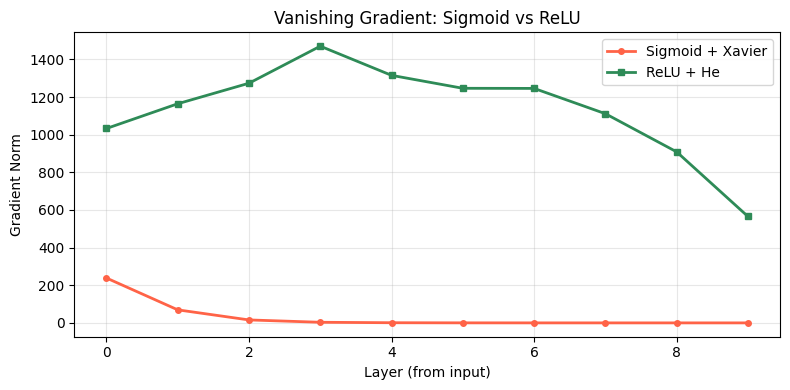

Sigmoid: gradient vanishes toward input layers
ReLU:    gradient stays stable across all layers


In [8]:
# Visualize vanishing gradient: Sigmoid vs ReLU
def grad_norms(activation, init_fn, n_layers=10):
    torch.manual_seed(0)
    layers = nn.ModuleList([nn.Linear(64, 64) for _ in range(n_layers)])
    for l in layers:
        init_fn(l.weight)
    x = torch.randn(32, 64, requires_grad=False)
    out = x
    for l in layers:
        out = activation(l(out))
    loss = out.sum()
    loss.backward()
    return [l.weight.grad.norm().item() for l in layers][::-1]  # first layer last

fig, ax = plt.subplots(figsize=(8, 4))
sigmoid_grads = grad_norms(torch.sigmoid, nn.init.xavier_uniform_)
relu_grads    = grad_norms(torch.relu,    nn.init.kaiming_uniform_)

ax.plot(sigmoid_grads, label='Sigmoid + Xavier', color='tomato',    lw=2, marker='o', markersize=4)
ax.plot(relu_grads,    label='ReLU + He',        color='seagreen',  lw=2, marker='s', markersize=4)
ax.set_xlabel("Layer (from input)"); ax.set_ylabel("Gradient Norm")
ax.set_title("Vanishing Gradient: Sigmoid vs ReLU")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("Sigmoid: gradient vanishes toward input layers")
print("ReLU:    gradient stays stable across all layers")


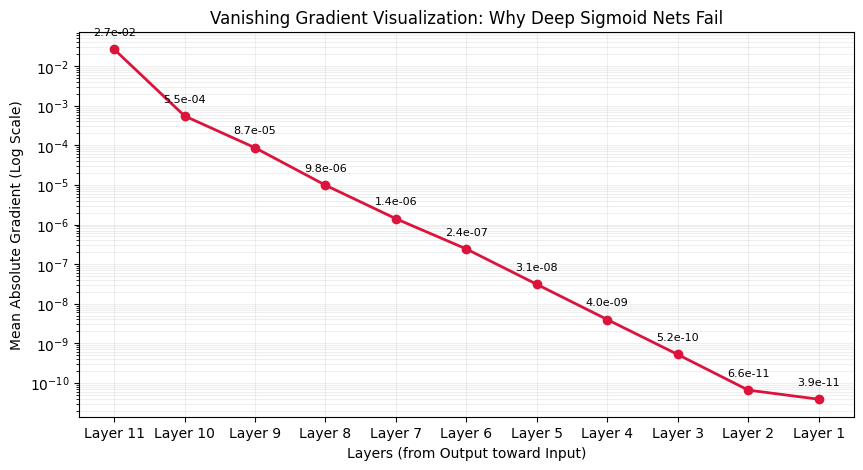

In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. 의도적으로 기울기 소실이 잘 일어나는 깊은 Sigmoid 모델 정의
torch.manual_seed(42)
layers = []
input_size = 2
for _ in range(10): # 10층의 깊은 구조
    layers.append(nn.Linear(input_size, 32))
    layers.append(nn.Sigmoid()) # 기울기 소실의 주범
    input_size = 32
layers.append(nn.Linear(32, 1))
layers.append(nn.Sigmoid())

model_a8 = nn.Sequential(*layers)

# 2. 가상의 데이터로 역전파 실행
X_dummy = torch.randn(32, 2)
y_dummy = torch.round(torch.rand(32, 1))
criterion = nn.BCELoss()

output = model_a8(X_dummy)
loss = criterion(output, y_dummy)
model_a8.zero_grad()
loss.backward()

# 3. 각 레이어의 Gradient Norm 수집
grad_norms = []
layer_names = []
linear_layers = [m for m in model_a8 if isinstance(m, nn.Linear)]

for i, layer in enumerate(reversed(linear_layers)):
    # weight의 gradient 절대값 평균(norm) 계산
    norm = layer.weight.grad.abs().mean().item()
    grad_norms.append(norm)
    layer_names.append(f"Layer {len(linear_layers)-i}")

# 4. 로그 스케일 시각화 (충격 요법)
plt.figure(figsize=(10, 5))
plt.plot(layer_names, grad_norms, marker='o', color='crimson', linestyle='-', linewidth=2)

plt.yscale('log') # 로그 스케일 적용
plt.xlabel("Layers (from Output toward Input)")
plt.ylabel("Mean Absolute Gradient (Log Scale)")
plt.title("Vanishing Gradient Visualization: Why Deep Sigmoid Nets Fail")
plt.grid(True, which="both", ls="-", alpha=0.2)

# 수치 텍스트 추가 (선택 사항)
for i, txt in enumerate(grad_norms):
    plt.annotate(f"{txt:.1e}", (layer_names[i], grad_norms[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.show()

## 6. 모두 합치기 — Best Practice

지금까지 배운 기법들을 한 번에 적용해봅시다.

| 기법 | 코드 |
|------|------|
| He 초기화 | `nn.Linear` 기본값 (Kaiming Uniform) |
| ReLU 활성화 | `nn.ReLU()` |
| Dropout | `nn.Dropout(p=0.3)` |
| L2 정규화 | `weight_decay=1e-3` in optimizer |
| train/eval 모드 | 루프마다 명시 |


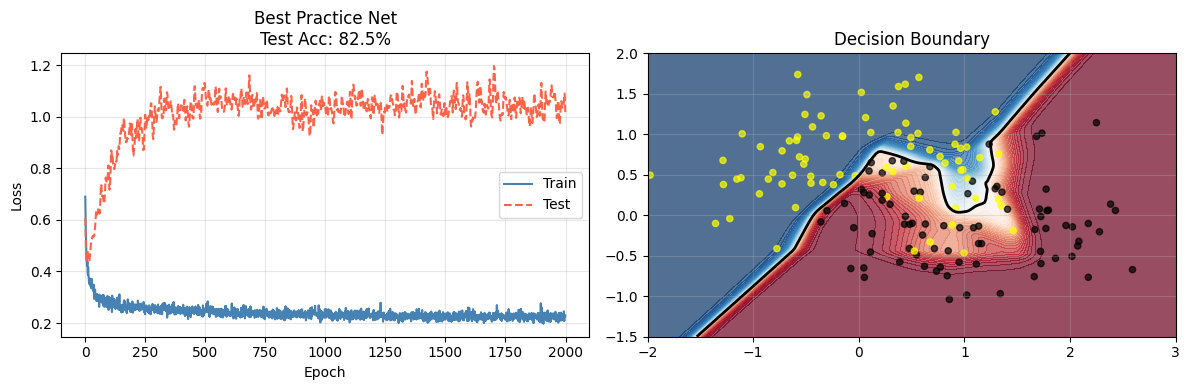

In [10]:
class BestPracticeNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, 1), nn.Sigmoid()
        )
        # He init is PyTorch default for nn.Linear — no extra code needed!

    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
best_model = BestPracticeNet(input_dim=2, hidden_dim=64, dropout_p=0.3)
optimizer  = torch.optim.Adam(best_model.parameters(), lr=0.01, weight_decay=1e-3)
criterion  = nn.BCELoss()

tr_best, te_best = [], []
for epoch in range(2000):
    best_model.train()
    optimizer.zero_grad()
    loss = criterion(best_model(X_train), y_train)
    loss.backward(); optimizer.step()
    tr_best.append(loss.item())
    best_model.eval()
    with torch.no_grad():
        te_best.append(criterion(best_model(X_test), y_test).item())

with torch.no_grad():
    acc_best = ((best_model(X_test)>0.5).float()==y_test).float().mean().item()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tr_best, label='Train', color='steelblue')
axes[0].plot(te_best, label='Test',  color='tomato', linestyle='--')
axes[0].set_title(f"Best Practice Net\nTest Acc: {acc_best*100:.1f}%")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

xx, yy = np.meshgrid(np.linspace(-2,3,200), np.linspace(-1.5,2,200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
best_model.eval()
with torch.no_grad():
    zz = best_model(grid).reshape(xx.shape).numpy()
axes[1].contourf(xx, yy, zz, levels=50, cmap='RdBu_r', alpha=0.7)
axes[1].contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2)
axes[1].scatter(X_tr[:,0], X_tr[:,1],
                c=['yellow' if l==0 else 'black' for l in y_tr], s=20, alpha=0.7)
axes[1].set_title("Decision Boundary"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 7. 다음 주 예고 — 최적화 알고리즘

6주차에서 **모델을 안정적으로 훈련하는 기법**을 익혔습니다.

7주차에서는 **더 빠르고 잘 수렴하는 학습 방법**을 다룹니다.

- 미니배치(Mini-batch): 전체 데이터 대신 일부만 사용
- Momentum: 이전 gradient 방향을 기억
- Adam: Momentum + 학습률 자동 조정 (우리가 계속 쓰던 것!)
- Learning rate schedule: 학습 중 학습률을 줄여가기

---
**Part 2 실습으로 넘어가세요 ↓**


---
# Part 2: 실습 (교실 100분)

> - `______` 를 올바른 코드로 채우세요.
> - [A]는 한 줄, [B]는 여러 줄 채우기입니다.

---

In [11]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

torch.manual_seed(42); np.random.seed(42)

X_np, y_np = make_moons(n_samples=200, noise=0.3, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_np, y_np, test_size=0.2, random_state=42)
X_train = torch.tensor(X_tr, dtype=torch.float32)
y_train = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(X_te, dtype=torch.float32)
y_test  = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)


## [A] 한 줄 채우기

---
### A-1. L2 정규화 — weight_decay 적용

아래 optimizer에 L2 정규화 ($\lambda = 10^{-3}$) 를 추가하세요.


In [12]:
model_a1 = nn.Sequential(nn.Linear(2,32), nn.ReLU(), nn.Linear(32,1), nn.Sigmoid())

# weight_decay 파라미터를 추가하세요
optimizer_a1 = ______

print(optimizer_a1)  # weight_decay=0.001 이 보여야 합니다


NameError: name '______' is not defined

---
### A-2. Dropout 레이어 삽입

아래 모델에 `nn.Dropout(p=0.3)` 을 올바른 위치에 삽입하세요.
(각 ReLU 뒤, 출력층 앞)


In [ ]:
model_a2 = nn.Sequential(
    nn.Linear(2, 64), nn.ReLU(),
    ______,                        # Dropout (첫 번째 은닉층 뒤)
    nn.Linear(64, 64), nn.ReLU(),
    ______,                        # Dropout (두 번째 은닉층 뒤)
    nn.Linear(64, 1), nn.Sigmoid()
)
print(model_a2)


---
### A-3. train() / eval() — Dropout 동작 차이 확인

같은 모델에서 `train()` 모드와 `eval()` 모드의 출력이 다른지 확인하세요.


In [ ]:
torch.manual_seed(0)
model_a3 = nn.Sequential(nn.Linear(2,8), nn.ReLU(), nn.Dropout(p=0.5), nn.Linear(8,1))
x_a3 = torch.ones(1, 2)

model_a3.______   # 훈련 모드
out_train = model_a3(x_a3)

model_a3.______   # 평가 모드
with torch.no_grad():
    out_eval = model_a3(x_a3)

print(f"train() output: {out_train.item():.4f}")
print(f"eval()  output: {out_eval.item():.4f}")
print("Different?", not torch.isclose(out_train, out_eval))


---
### A-4. Sigmoid 기울기 계산

Sigmoid의 기울기(도함수)를 수식으로 직접 계산하세요.

$$\sigma'(z) = \sigma(z)\,(1 - \sigma(z))$$


In [ ]:
z = torch.tensor([-3.0, -1.0, 0.0, 1.0, 3.0], requires_grad=True)

# 방법 1: 수식으로 직접
sig = torch.sigmoid(z)
my_grad = ______   # σ(z) * (1 - σ(z))

# 방법 2: autograd 로 확인
sig.sum().backward()
autograd_grad = z.grad

print("My grad:      ", my_grad.detach().round(decimals=4))
print("Autograd grad:", autograd_grad.round(decimals=4))
print("Match:", torch.allclose(my_grad.detach(), autograd_grad))
print(f"\nMax gradient of Sigmoid: {my_grad.max().item():.4f}  (at z=0)")
print("→ Always ≤ 0.25, so deep Sigmoid nets suffer vanishing gradients!")


---
### A-5. Xavier 초기화 적용

아래 레이어에 Xavier Uniform 초기화를 적용하세요.


In [ ]:
torch.manual_seed(0)
layer_a5 = nn.Linear(64, 32)

print("Before Xavier init:")
print(f"  weight std: {layer_a5.weight.std().item():.4f}")

# Xavier Uniform 초기화 적용 (nn.init 사용)
______

print("After Xavier init:")
print(f"  weight std: {layer_a5.weight.std().item():.4f}")
# 예상값: sqrt(6 / (64+32)) ≈ 0.25


---
### A-6. He 초기화 적용

ReLU에 맞는 He (Kaiming) 초기화를 적용하세요.


In [ ]:
torch.manual_seed(0)
layer_a6 = nn.Linear(64, 32)

print("Before He init:")
print(f"  weight std: {layer_a6.weight.std().item():.4f}")

# He (Kaiming Normal) 초기화 적용
______

print("After He init:")
print(f"  weight std: {layer_a6.weight.std().item():.4f}")
# 예상값: sqrt(2 / 64) ≈ 0.177


---
### A-7. L2 정규화 수식으로 직접 구현

`weight_decay` 대신 수식으로 직접 L2 penalty를 loss에 더하세요.

$$\mathcal{L}_{\text{reg}} = \mathcal{L}_{\text{BCE}} + \frac{\lambda}{2} \sum_{l} \|W^{[l]}\|_F^2$$


In [ ]:
torch.manual_seed(42)
model_a7 = nn.Sequential(nn.Linear(2,16), nn.ReLU(), nn.Linear(16,1), nn.Sigmoid())
lambda_  = 1e-3
crit_a7  = nn.BCELoss()

pred   = model_a7(X_train)
bce    = crit_a7(pred, y_train)

# L2 penalty: 모든 weight 파라미터의 제곱합
l2_penalty = ______

loss_reg = bce + lambda_ * l2_penalty

print(f"BCE loss:    {bce.item():.6f}")
print(f"L2 penalty:  {l2_penalty.item():.6f}")
print(f"Total loss:  {loss_reg.item():.6f}")


---
### A-8. gradient norm 계산

학습 후 각 레이어의 gradient norm을 계산하여 vanishing gradient를 확인하세요.


In [ ]:
torch.manual_seed(42)
model_a8 = nn.Sequential(
    nn.Linear(2,32),  nn.Sigmoid(),
    nn.Linear(32,32), nn.Sigmoid(),
    nn.Linear(32,32), nn.Sigmoid(),
    nn.Linear(32,1),  nn.Sigmoid()
)
loss_a8 = nn.BCELoss()(model_a8(X_train), y_train)
loss_a8.backward()

print("Gradient norms (from output → input):")
linear_layers = [m for m in model_a8 if isinstance(m, nn.Linear)]
for i, layer in enumerate(reversed(linear_layers)):
    # 각 레이어 weight의 gradient norm을 한 줄로 계산하세요
    grad_norm = ______
    print(f"  Layer {len(linear_layers)-i} (closer to output): grad norm = {grad_norm:.6f}")
print("→ gradient norm이 input 쪽으로 갈수록 줄어드는지 확인하세요!")


---
## [B] 여러 줄 채우기

---
### B-1. 정규화 기법 비교 실험

아래 4가지 조건을 **동일한 모델 구조**로 비교하세요.

| 조건 | 설명 |
|------|------|
| Baseline | 정규화 없음 |
| L2 only | weight_decay=1e-3 |
| Dropout only | p=0.3 |
| L2 + Dropout | 둘 다 적용 |

**목표**: 각 조건의 Train Loss, Test Loss, Test Accuracy를 비교하는 표를 출력하세요.


In [ ]:
def make_model_with_dropout(dropout_p=0.0):
    """dropout_p=0.0 이면 Dropout 없음"""
    layers = [nn.Linear(2,64), nn.ReLU()]
    if dropout_p > 0: layers.append(nn.Dropout(dropout_p))
    layers += [nn.Linear(64,64), nn.ReLU()]
    if dropout_p > 0: layers.append(nn.Dropout(dropout_p))
    layers += [nn.Linear(64,1), nn.Sigmoid()]
    return nn.Sequential(*layers)

def run_experiment(dropout_p, weight_decay, epochs=2000):
    """모델 학습 후 (final_train_loss, final_test_loss, test_acc) 반환"""
    torch.manual_seed(42)
    model = make_model_with_dropout(dropout_p)
    ______   # optimizer (weight_decay 포함)
    ______   # loss function

    for _ in range(epochs):
        ______  # train 모드
        ______; ______; ______; ______; ______

    model.eval()
    with torch.no_grad():
        ______   # train loss
        ______   # test loss
        ______   # test accuracy

    return final_train, final_test, acc

conditions = {
    "Baseline":       dict(dropout_p=0.0, weight_decay=0.0),
    "L2 only":        dict(dropout_p=0.0, weight_decay=1e-3),
    "Dropout only":   dict(dropout_p=0.3, weight_decay=0.0),
    "L2 + Dropout":   dict(dropout_p=0.3, weight_decay=1e-3),
}

print(f"{'Condition':20s} {'Train Loss':>12s} {'Test Loss':>10s} {'Test Acc':>10s}")
print("-" * 58)
for name, kwargs in conditions.items():
    tr_l, te_l, acc = run_experiment(**kwargs)
    print(f"{name:20s} {tr_l:>12.4f} {te_l:>10.4f} {acc*100:>9.1f}%")


---
### B-2. (숙제 가능) 초기화 전략 비교

아래 세 가지 초기화 전략을 비교하는 실험을 설계하고 실행하세요.

- **Zero init**: 모든 가중치를 0으로
- **Small random**: $\mathcal{N}(0, 0.01)$ 로 초기화
- **He init**: `nn.init.kaiming_normal_` (권장)

**목표**:
1. 각 초기화 전략으로 학습 후 Loss 곡선 비교
2. 첫 번째 레이어의 gradient norm 비교
3. 결론: 어떤 초기화가 왜 좋은지 설명

힌트:
```python
# 특정 초기화 함수를 모든 Linear 레이어에 적용
def apply_init(model, init_fn):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            init_fn(m.weight)
            nn.init.zeros_(m.bias)
```


In [ ]:
def apply_init(model, init_fn):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            init_fn(m.weight)
            nn.init.zeros_(m.bias)

def train_with_init(init_fn, label, epochs=1000):
    """초기화 함수를 받아 학습 후 losses 반환"""
    ______
    ______
    ______   # apply_init 적용
    ______
    ______

    losses = []
    for _ in range(epochs):
        ______; ______; ______; ______; ______
        losses.append(______)

    # 첫 번째 Linear 레이어의 gradient norm
    with torch.no_grad():
        first_linear = [m for m in model.modules() if isinstance(m, nn.Linear)][0]
        grad_norm = first_linear.weight.grad.norm().item() if first_linear.weight.grad is not None else 0.0

    return losses, grad_norm

init_strategies = {
    "Zero init":      lambda w: nn.init.zeros_(w),
    "Small random":   lambda w: nn.init.normal_(w, 0, 0.01),
    "He init":        lambda w: nn.init.kaiming_normal_(w),
}

fig, ax = plt.subplots(figsize=(8, 4))
for label, init_fn in init_strategies.items():
    losses, grad_norm = train_with_init(init_fn, label)
    ______   # Loss 곡선
    print(f"{label:15s}: final loss={losses[-1]:.4f}, first layer grad norm={grad_norm:.6f}")

ax.set_xlabel("Epoch"); ax.set_ylabel("Train Loss")
ax.set_title("Initialization Strategy Comparison")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


---
## ✅ 체크리스트

- [ ] Train/Test Loss 곡선으로 Overfitting vs Underfitting을 진단할 수 있다
- [ ] `weight_decay` 파라미터로 L2 정규화를 적용했다
- [ ] `nn.Dropout`을 올바른 위치에 삽입했다
- [ ] `model.train()` / `model.eval()` 이 Dropout에 영향을 준다는 것을 확인했다
- [ ] Xavier / He 초기화의 차이와 사용 기준을 이해했다
- [ ] gradient norm으로 Vanishing Gradient를 직접 확인했다

---
## 💭 생각해볼 질문

1. Dropout을 평가(eval) 모드에서도 켜두면 어떤 문제가 생길까요?

2. L2 정규화는 가중치를 0으로 만드는 경향이 있습니다. 그렇다면 가중치를 **정확히 0으로** 만들고 싶다면 어떤 정규화를 써야 할까요? (힌트: L1)

3. ReLU는 Vanishing Gradient 문제를 어떻게 해결하나요? 반면 ReLU의 단점은 무엇인가요? (힌트: Dead ReLU)
